# Training history comparison: datasets A and B

This notebook gives a concise comparison of the PPO training histories for datasets A and B. It focuses on reward, spherical margin, success rate, and curriculum stage. No model inference or rollout evaluation is performed.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
while not (project_root / 'src').exists() and project_root != project_root.parent:
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise FileNotFoundError('Could not find the src folder from the current working directory.')

log_paths = {
    'Dataset A': project_root / 'results' / 'A_seed0' / 'train_log.npz',
    'Dataset B': project_root / 'results' / 'B_seed0' / 'train_log.npz',
}

histories = {}
for name, path in log_paths.items():
    if not path.exists():
        raise FileNotFoundError(f'Missing training log: {path}')
    histories[name] = dict(np.load(path))

print(f'Project root: {project_root}')
print('Loaded:', ', '.join(log_paths))

Project root: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds
Loaded: Dataset A, Dataset B


## Summary statistics

The table reports the first and last logged values, together with the best observed value during training.

In [2]:
summary_rows = []
for dataset, history in histories.items():
    summary_rows.append({
        'dataset': dataset,
        'updates': len(history['timesteps']),
        'final_timesteps': int(history['timesteps'][-1]),
        'reward_first': history['reward'][0],
        'reward_final': history['reward'][-1],
        'reward_best': history['reward'].max(),
        'margin_first': history['margin'][0],
        'margin_final': history['margin'][-1],
        'margin_best': history['margin'].max(),
        'success_first': history['success_rate'][0],
        'success_final': history['success_rate'][-1],
        'success_best': history['success_rate'].max(),
        'final_stage': int(history['stage'][-1]),
    })

summary = pd.DataFrame(summary_rows).set_index('dataset')
display(summary.style.format({
    'reward_first': '{:.3f}', 'reward_final': '{:.3f}', 'reward_best': '{:.3f}',
    'margin_first': '{:.3f}', 'margin_final': '{:.3f}', 'margin_best': '{:.3f}',
    'success_first': '{:.1%}', 'success_final': '{:.1%}', 'success_best': '{:.1%}',
}))

,updates,final_timesteps,reward_first,reward_final,reward_best,margin_first,margin_final,margin_best,success_first,success_final,success_best,final_stage
dataset,,,,,,,,,,,,
Dataset A,1953,1999872,-0.888,-0.539,-0.447,-2.092,-1.418,-0.740,35.0%,99.3%,100.0%,3
Dataset B,1953,1999872,-0.737,0.096,0.359,-1.492,0.180,0.653,71.8%,99.7%,100.0%,3


## Training curves

The vertical dashed lines mark curriculum-stage changes. The reward and margin curves are shown as logged by the training loop; they are not smoothed.

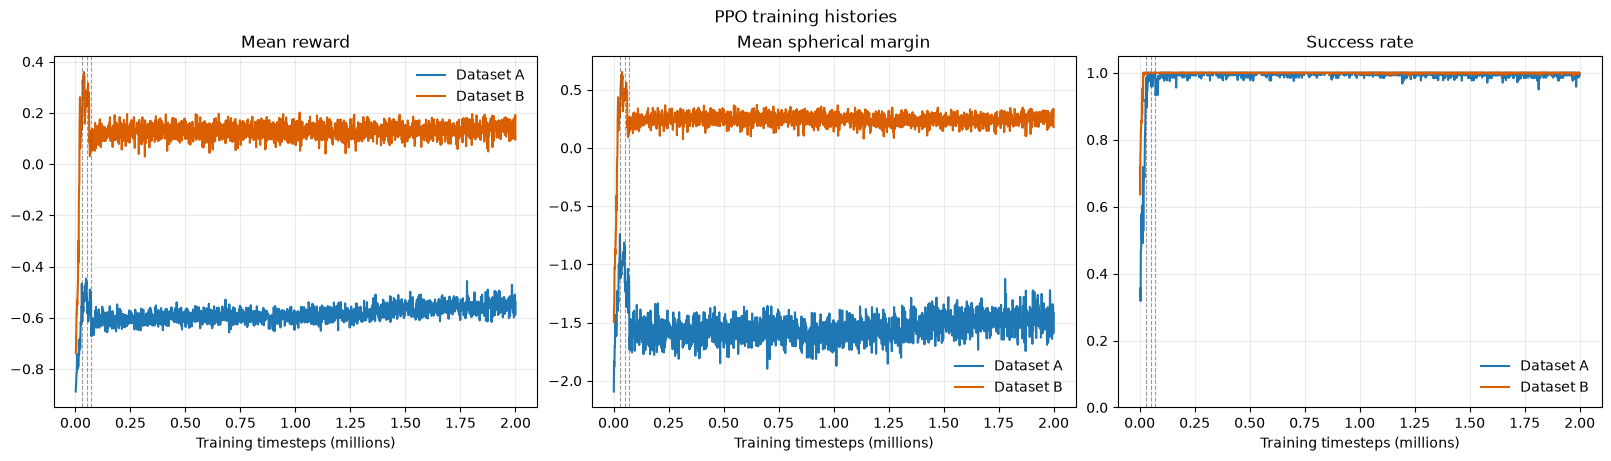

In [4]:
colors = {'Dataset A': '#1f77b4', 'Dataset B': '#d95f02'}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

for dataset, history in histories.items():
    x = history['timesteps'] / 1_000_000
    color = colors[dataset]
    axes[0].plot(x, history['reward'], label=dataset, color=color, linewidth=1.5)
    axes[1].plot(x, history['margin'], label=dataset, color=color, linewidth=1.5)
    axes[2].plot(x, history['success_rate'], label=dataset, color=color, linewidth=1.5)

stage_history = histories['Dataset A']
stage_changes = np.flatnonzero(np.diff(stage_history['stage'])) + 1
for change_index in stage_changes:
    change_x = stage_history['timesteps'][change_index] / 1_000_000
    for ax in axes:
        ax.axvline(change_x, color='0.35', linestyle='--', linewidth=0.8, alpha=0.6)

for ax in axes:
    ax.set_xlabel('Training timesteps (millions)')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

axes[0].set_title('Mean reward')
axes[1].set_title('Mean spherical margin')
axes[2].set_title('Success rate')
axes[2].set_ylim(0, 1.05)
fig.suptitle('PPO training histories')
plt.show()

In [5]:
print('Main points')
for dataset, history in histories.items():
    print(
        f"{dataset}: reward {history['reward'][0]:+.3f} -> {history['reward'][-1]:+.3f}; "
        f"margin {history['margin'][0]:+.3f} -> {history['margin'][-1]:+.3f}; "
        f"success rate {history['success_rate'][0]:.1%} -> {history['success_rate'][-1]:.1%}; "
        f"best success rate {history['success_rate'].max():.1%}."
    )

print('Both runs reached the final curriculum stage and logged the same training horizon.')
print('Dataset B shows the stronger improvement in reward and margin, while both datasets finish near-perfect on the logged success metric.')

Main points
Dataset A: reward -0.888 -> -0.539; margin -2.092 -> -1.418; success rate 35.0% -> 99.3%; best success rate 100.0%.
Dataset B: reward -0.737 -> +0.096; margin -1.492 -> +0.180; success rate 71.8% -> 99.7%; best success rate 100.0%.
Both runs reached the final curriculum stage and logged the same training horizon.
Dataset B shows the stronger improvement in reward and margin, while both datasets finish near-perfect on the logged success metric.


## Uma curiosidade sobre o margin médio

O `margin` mostrado acima é uma média por passo, enquanto o sucesso encerra um episódio e inclui o estado terminal no lote. Por isso, um margin médio positivo não implica que a maior parte dos estados seja spherical: poucos valores positivos, se forem suficientemente grandes em módulo, podem compensar muitos valores negativos pequenos em módulo.

In [6]:
for dataset, history in histories.items():
    margin = history['margin']
    positive_fraction = np.mean(margin > 0)
    print(
        f"{dataset}: {positive_fraction:.1%} dos updates têm margin médio positivo; "
        f"média global = {margin.mean():+.3f}; "
        f"maior valor = {margin.max():+.3f}."
    )

print(
    "Essa comparação ajuda a distinguir frequência de magnitude: "
    "a média pode ser positiva mesmo quando os valores positivos são minoria."
)

Dataset A: 0.0% dos updates têm margin médio positivo; média global = -1.540; maior valor = -0.740.
Dataset B: 99.1% dos updates têm margin médio positivo; média global = +0.241; maior valor = +0.653.
Essa comparação ajuda a distinguir frequência de magnitude: a média pode ser positiva mesmo quando os valores positivos são minoria.


A leitura desta checagem é específica para os dados acima: o Dataset B tem média positiva em quase todos os updates, enquanto o Dataset A permanece negativo. Isso não mede a fração de estados individuais positivos; mede apenas a fração de batches de treinamento cuja média ficou acima de zero. A diferença é compatível com B visitar estados mais próximos da região spherical e alcançar com mais frequência margens positivos durante a coleta.